## Datathon FIAP — Associação Passos Mágicos

## Objetivo do projeto

Este projeto tem como objetivo analisar os indicadores educacionais, psicossociais e psicopedagógicos da Associação Passos Mágicos, utilizando técnicas de Data Analytics e Machine Learning para identificar padrões de desempenho, engajamento e risco educacional.

Além da análise exploratória e construção de storytelling analítico, também foi desenvolvido um modelo preditivo capaz de estimar a probabilidade de risco educacional dos alunos, permitindo ações preventivas e acompanhamento direcionado.


## Problema de negócio

A Associação Passos Mágicos atua na transformação da vida de crianças e jovens em vulnerabilidade social por meio da educação.

Diante disso, o principal desafio deste projeto foi responder questões estratégicas relacionadas a:

- Defasagem educacional;
- Evolução do desempenho acadêmico;
- Engajamento dos alunos;
- Aspectos psicossociais;
- Avaliações psicopedagógicas;
- Identificação antecipada de risco educacional.


## IMPORTS

In [2]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Base utilizada

Foram utilizadas as bases históricas do PEDE referentes aos anos:

- 2022
- 2023
- 2024

As bases possuem indicadores acadêmicos, emocionais, psicossociais e educacionais dos alunos acompanhados pela instituição.

# TRATAMENTO DOS DADOS

## Padronização das bases

As bases dos anos de 2022, 2023 e 2024 apresentavam diferenças estruturais entre nomes de colunas, variáveis e organização dos dados.

Por isso, foi necessário realizar:

- Renomeação de colunas;
- Padronização de indicadores;
- Conversão de tipos de dados;
- Tratamento de valores ausentes;
- Consolidação em uma única base histórica.

In [3]:
arquivo = "X:/POS/DESAFIO_5_DATATHON/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

abas = pd.ExcelFile(arquivo).sheet_names
print(abas)

df_2022 = pd.read_excel(arquivo, sheet_name="PEDE2022")
df_2023 = pd.read_excel(arquivo, sheet_name="PEDE2023")
df_2024 = pd.read_excel(arquivo, sheet_name="PEDE2024")

print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)

['PEDE2022', 'PEDE2023', 'PEDE2024']
2022: (860, 42)
2023: (1014, 48)
2024: (1156, 50)


## Criação da variável ANO

Foi criada a coluna ANO para identificar o período de origem de cada registro e permitir análises evolutivas ao longo do tempo.

---

## Padronização de categorias

Algumas variáveis categóricas apresentavam inconsistências, como:

- ÁGATA / AGATA
- Valores nulos
- Categorias duplicadas

Foi realizado tratamento textual para garantir consistência analítica.

---

## Tratamento de valores ausentes

Foram identificados valores ausentes em diversos indicadores, especialmente no IPP.

As estratégias adotadas incluíram:

- Remoção de registros inválidos em análises específicas;
- Preenchimento com mediana em variáveis numéricas do modelo;
- Padronização de categorias desconhecidas.

In [4]:
for ano, df in {
    "2022": df_2022,
    "2023": df_2023,
    "2024": df_2024
}.items():
    print(f"\n===== PEDE {ano} =====")
    display(df.head())
    print(df.info())


===== PEDE 2022 =====


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [5]:
def resumo_nulos(df):
    return (
        df.isna()
        .sum()
        .reset_index()
        .rename(columns={"index": "coluna", 0: "qtd_nulos"})
        .assign(percentual_nulos=lambda x: x["qtd_nulos"] / len(df) * 100)
        .sort_values("percentual_nulos", ascending=False)
    )

resumo_nulos(df_2024).head(30)

,coluna,qtd_nulos,percentual_nulos
19,Ct,1156,100.000000
44,Destaque IEG,1156,100.000000
33,Rec Psicologia,1156,100.000000
24,Rec Av2,1156,100.000000
22,Rec Av1,1156,100.000000
39,Atingiu PV,1156,100.000000
18,Cf,1156,100.000000
17,Cg,1156,100.000000
38,Indicado,1156,100.000000
45,Destaque IDA,1156,100.000000


## 3- CONSOLIDAÇÃO DAS BASES

In [6]:
df22 = df_2022.copy()

base22 = pd.DataFrame({
    "RA": df22["RA"],
    "ANO": 2022,
    "FASE": df22["Fase"],
    "TURMA": df22["Turma"],
    "NOME": df22["Nome"],
    "IDADE": df22["Idade 22"],
    "GENERO": df22["Gênero"],
    "ANO_INGRESSO": df22["Ano ingresso"],
    "INSTITUICAO_ENSINO": df22["Instituição de ensino"],
    "PEDRA": df22["Pedra 22"],
    "INDE": df22["INDE 22"],
    "IAA": df22["IAA"],
    "IEG": df22["IEG"],
    "IPS": df22["IPS"],
    "IPP": np.nan,
    "IDA": df22["IDA"],
    "IPV": df22["IPV"],
    "IAN": df22["IAN"],
    "DEFASAGEM": df22["Defas"],
    "PONTO_VIRADA": df22["Atingiu PV"],
    "MAT": df22["Matem"],
    "PORT": df22["Portug"],
    "ING": df22["Inglês"]
})
#######-------------############
df23 = df_2023.copy()

base23 = pd.DataFrame({
    "RA": df23["RA"],
    "ANO": 2023,
    "FASE": df23["Fase"],
    "TURMA": df23["Turma"],
    "NOME": df23["Nome Anonimizado"],
    "IDADE": df23["Idade"],
    "GENERO": df23["Gênero"],
    "ANO_INGRESSO": df23["Ano ingresso"],
    "INSTITUICAO_ENSINO": df23["Instituição de ensino"],
    "PEDRA": df23["Pedra 2023"],
    "INDE": df23["INDE 23"],
    "IAA": df23["IAA"],
    "IEG": df23["IEG"],
    "IPS": df23["IPS"],
    "IPP": df23["IPP"],
    "IDA": df23["IDA"],
    "IPV": df23["IPV"],
    "IAN": df23["IAN"],
    "DEFASAGEM": df23["Defasagem"],
    "PONTO_VIRADA": df23["Atingiu PV"],
    "MAT": df23["Mat"],
    "PORT": df23["Por"],
    "ING": df23["Ing"]
})
###############-----------------#####################
df24 = df_2024.copy()

# substituir valores estranhos
df24.replace(1865, np.nan, inplace=True)

base24 = pd.DataFrame({
    "RA": df24["RA"],
    "ANO": 2024,
    "FASE": df24["Fase"],
    "TURMA": df24["Turma"],
    "NOME": df24["Nome Anonimizado"],
    "IDADE": df24["Idade"],
    "GENERO": df24["Gênero"],
    "ANO_INGRESSO": df24["Ano ingresso"],
    "INSTITUICAO_ENSINO": df24["Instituição de ensino"],
    "PEDRA": df24["Pedra 2024"],
    "INDE": df24["INDE 2024"],
    "IAA": df24["IAA"],
    "IEG": df24["IEG"],
    "IPS": df24["IPS"],
    "IPP": df24["IPP"],
    "IDA": df24["IDA"],
    "IPV": df24["IPV"],
    "IAN": df24["IAN"],
    "DEFASAGEM": df24["Defasagem"],
    "PONTO_VIRADA": df24["Atingiu PV"],
    "MAT": df24["Mat"],
    "PORT": df24["Por"],
    "ING": df24["Ing"],
    "ESCOLA": df24["Escola"],
    "STATUS": df24["Ativo/ Inativo"]
})

In [7]:
df_final = pd.concat(
    [base22, base23, base24],
    ignore_index=True
)

print(df_final.shape)
df_final.head()

(3030, 25)


,RA,ANO,FASE,TURMA,NOME,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,PEDRA,...,IDA,IPV,IAN,DEFASAGEM,PONTO_VIRADA,MAT,PORT,ING,ESCOLA,STATUS
0,RA-1,2022,7,A,Aluno-1,19,Menina,2016,Escola Pública,Quartzo,...,4.0,7.278,5.0,-1,Não,2.7,3.5,6.0,NaN,NaN
1,RA-2,2022,7,A,Aluno-2,17,Menina,2017,Rede Decisão,Ametista,...,6.8,6.778,10.0,0,Não,6.3,4.5,9.7,NaN,NaN
2,RA-3,2022,7,A,Aluno-3,17,Menina,2016,Rede Decisão,Ágata,...,5.6,7.556,10.0,0,Não,5.8,4.0,6.9,NaN,NaN
3,RA-4,2022,7,A,Aluno-4,17,Menino,2017,Rede Decisão,Quartzo,...,5.0,5.278,10.0,0,Não,2.8,3.5,8.7,NaN,NaN
4,RA-5,2022,7,A,Aluno-5,17,Menina,2016,Rede Decisão,Ametista,...,5.2,7.389,10.0,0,Não,7.0,2.9,5.7,NaN,NaN


In [8]:
cols_texto = [
    "NOME",
    "GENERO",
    "FASE",
    "PEDRA",
    "INSTITUICAO_ENSINO"
]

for col in cols_texto:
    df_final[col] = (
        df_final[col]
        .astype(str)
        .str.upper()
        .str.strip()
    )

In [9]:
cols_num = [
    "INDE",
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "IPV",
    "IAN",
    "MAT",
    "PORT",
    "ING"
]

for col in cols_num:
    df_final[col] = pd.to_numeric(
        df_final[col],
        errors="coerce"
    )

# Feature Engineering

## Objetivo

O processo de Feature Engineering teve como objetivo criar variáveis mais interpretáveis e relevantes para análise e modelagem preditiva.

---

## Faixas de defasagem (IAN)

O indicador IAN foi convertido em categorias interpretáveis:

- Adequado
- Defasagem moderada
- Defasagem severa

Essa transformação facilitou análises gerenciais e comparações entre grupos.

---

## Faixas de engajamento (IEG)

O indicador de engajamento foi segmentado em:

- Alto
- Moderado
- Baixo

Permitindo identificar padrões de comportamento e relação com desempenho acadêmico.

---

## Faixas psicossociais (IPS)

O IPS foi categorizado em:

- Estável
- Atenção
- Crítico

Com o objetivo de identificar possíveis sinais de vulnerabilidade emocional.

---

## Variável de risco educacional

Foi criada uma variável-alvo binária chamada RISCO.

Foram considerados em risco alunos que apresentavam sinais de vulnerabilidade educacional, incluindo:

- IAN baixo;
- IDA baixo;
- IEG baixo.

Essa abordagem tornou o problema mais aderente ao contexto real de negócio da instituição.

---

## Encoding de variáveis categóricas

Variáveis categóricas foram transformadas utilizando One-Hot Encoding para utilização no modelo de Machine Learning.

Exemplos:

- Pedra
- Macro fase
- Gênero

# ANÁLISE 1 — DEFASAGEM EDUCACIONAL (IAN)

## Pergunta de negócio

Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo do tempo?

---

## Estratégia analítica

Foi realizada análise descritiva do indicador IAN e categorização dos alunos em faixas de adequação.

Também foram analisadas:

- Evolução anual;
- Distribuição por fase;
- Relação com desempenho acadêmico.

---

In [10]:
df_final["IAN"].describe()

count    3030.000000
mean        7.179043
std         2.535266
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64

In [11]:
def classificar_ian(valor):

    if pd.isna(valor):
        return np.nan

    elif valor >= 8:
        return "ADEQUADO"

    elif valor >= 6:
        return "DEFASAGEM LEVE"

    elif valor >= 4:
        return "DEFASAGEM MODERADA"

    else:
        return "DEFASAGEM SEVERA"


df_final["FAIXA_IAN"] = df_final["IAN"].apply(classificar_ian)

In [12]:
df_final["FAIXA_IAN"].value_counts(normalize=True) * 100

FAIXA_IAN
DEFASAGEM MODERADA    54.191419
ADEQUADO              44.323432
DEFASAGEM SEVERA       1.485149
Name: proportion, dtype: float64

In [13]:
evolucao_ian = pd.crosstab(
    df_final["ANO"],
    df_final["FAIXA_IAN"],
    normalize="index"
) * 100

evolucao_ian

FAIXA_IAN,ADEQUADO,DEFASAGEM MODERADA,DEFASAGEM SEVERA
ANO,,,
2022,30.116279,66.627907,3.255814
2023,45.562130,53.057199,1.380671
2024,53.806228,45.934256,0.259516


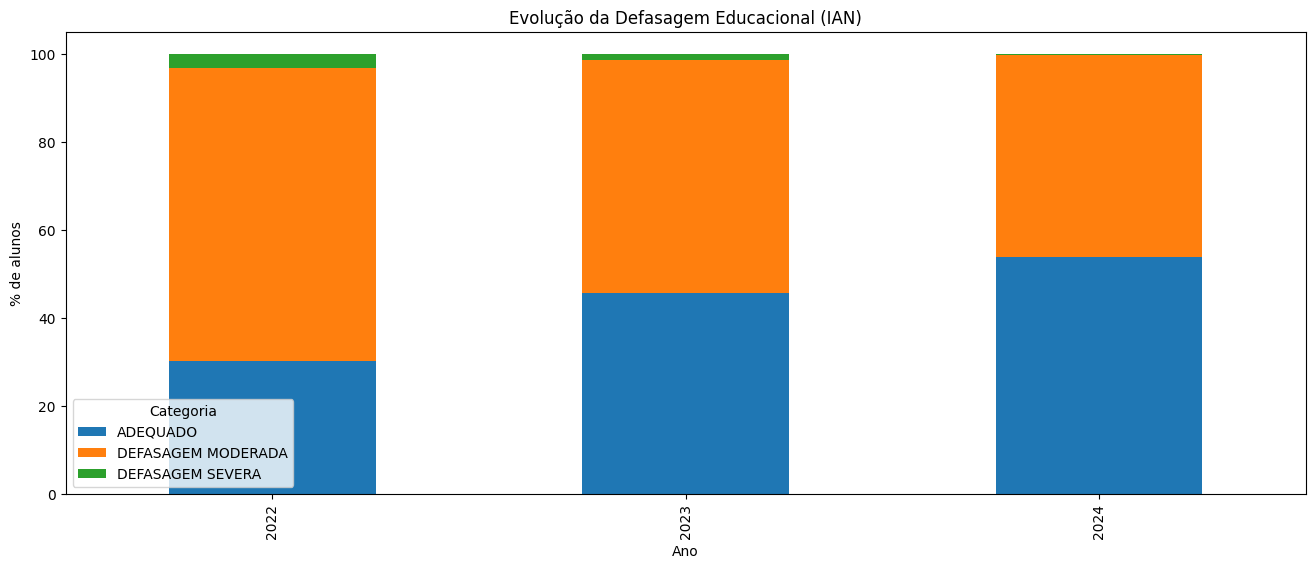

In [14]:
evolucao_ian.plot(
    kind="bar",
    stacked=True,
    figsize=(16,6)
)

plt.title("Evolução da Defasagem Educacional (IAN)")
plt.ylabel("% de alunos")
plt.xlabel("Ano")
plt.legend(title="Categoria")
plt.show()

### Criação da coluna macrofase


A variável FASE possuía muitas subdivisões granulares.

Foi criada a variável MACRO_FASE para agrupar fases semelhantes e reduzir ruído analítico, facilitando visualizações e modelagem preditiva.

In [15]:
df_final["FASE_ORIGINAL"] = df_final["FASE"]

df_final["MACRO_FASE"] = (
    df_final["FASE"]
    .astype(str)
    .str.upper()
    .str.extract(r'(\d+)')
)

df_final["MACRO_FASE"] = np.where(
    df_final["FASE"].astype(str).str.upper().str.contains("ALFA"),
    "ALFA",
    df_final["MACRO_FASE"]
)

df_final["MACRO_FASE"] = "FASE " + df_final["MACRO_FASE"].astype(str)
df_final["MACRO_FASE"] = df_final["MACRO_FASE"].replace("FASE NAN", np.nan)

In [16]:
fase_ian = pd.crosstab(
    df_final["MACRO_FASE"],
    df_final["FAIXA_IAN"],
    normalize="index"
) * 100

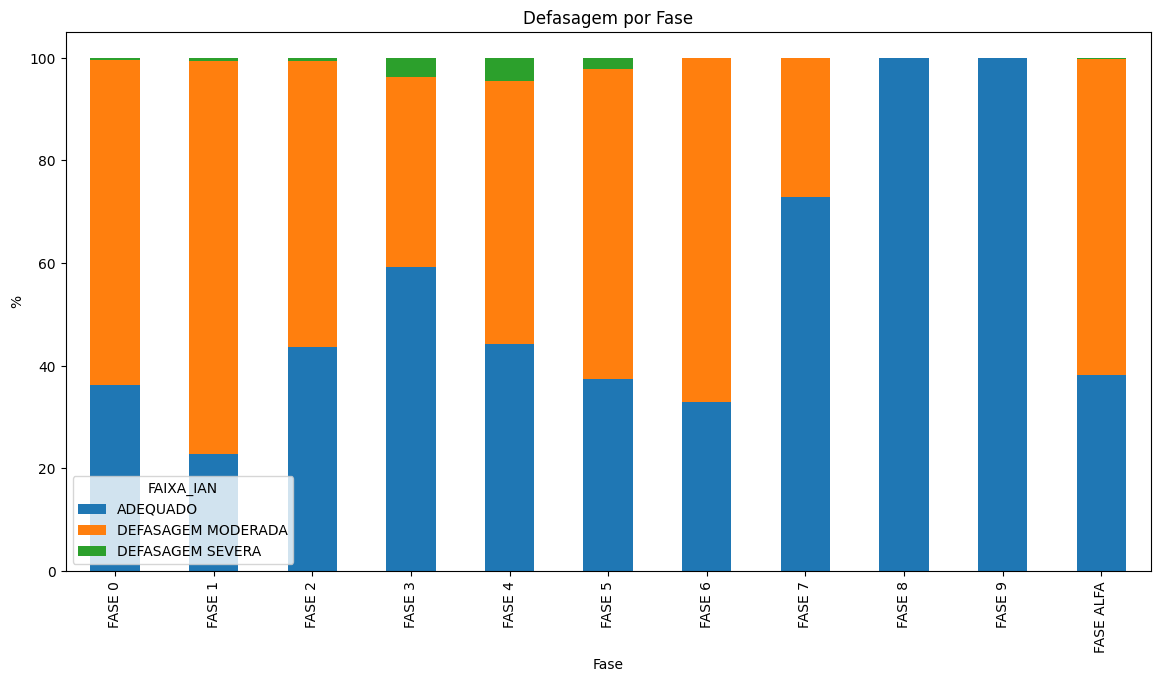

In [17]:
fase_ian.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Defasagem por Fase")
plt.ylabel("%")
plt.xlabel("Fase")
plt.show()

## Evidências encontradas

Os dados demonstraram predominância de alunos em defasagem moderada, porém com melhora progressiva ao longo dos anos.

Observou-se aumento do percentual de alunos classificados como adequados entre 2022 e 2024.

A defasagem severa permaneceu relativamente baixa.

---

## Resposta

Os resultados indicam evolução positiva da adequação educacional dos alunos ao longo do período analisado.

Apesar da existência de grupos em defasagem moderada, os indicadores sugerem melhora consistente do nível educacional médio.

---

# ANÁLISE 2 — DESEMPENHO ACADÊMICO (IDA)

## Pergunta de negócio

O desempenho acadêmico médio está melhorando, estagnado ou caindo ao longo dos anos?

---

## Estratégia analítica

Foi analisada a evolução do indicador IDA:

- Por ano;
- Por fase;
- Por pedra educacional.

Também foi investigada a relação entre desempenho e adequação educacional.

In [18]:
df_final["IDA"].describe()

count    2852.000000
mean        6.375964
std         1.956637
min         0.000000
25%         5.100000
50%         6.666667
75%         7.833333
max        10.000000
Name: IDA, dtype: float64

In [19]:
ida_ano = (
    df_final
    .groupby("ANO")["IDA"]
    .mean()
    .reset_index()
)

ida_ano

,ANO,IDA
0,2022,6.092907
1,2023,6.663394
2,2024,6.351422


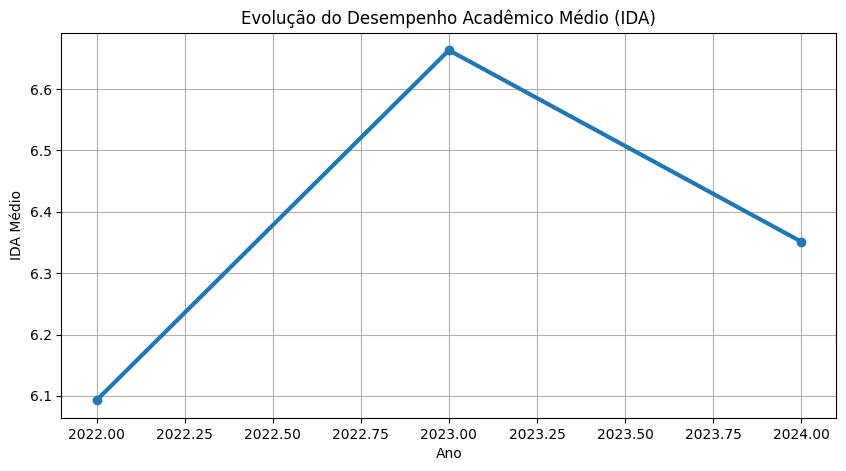

In [20]:

plt.figure(figsize=(10,5))

plt.plot(
    ida_ano["ANO"],
    ida_ano["IDA"],
    marker="o",
    linewidth=3
)

plt.title("Evolução do Desempenho Acadêmico Médio (IDA)")
plt.xlabel("Ano")
plt.ylabel("IDA Médio")

plt.grid(True)

plt.show()

### DISTRIBUICAO DO IDA

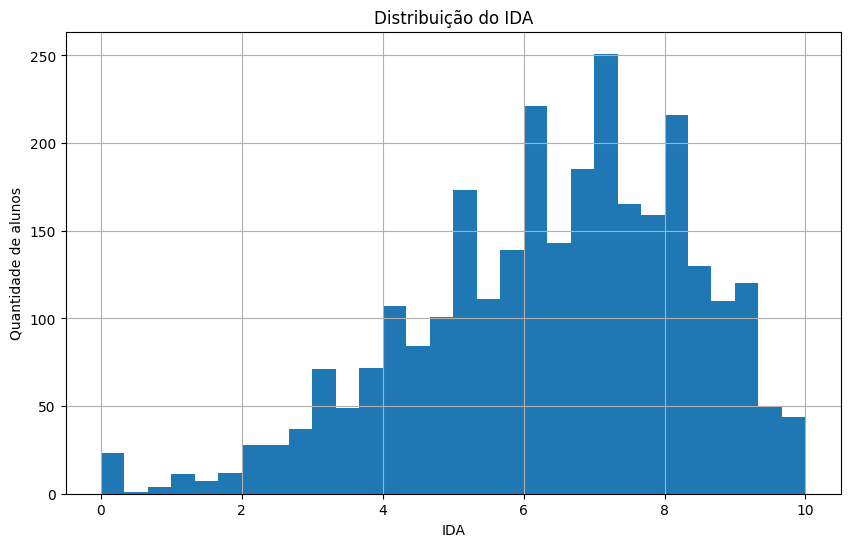

In [21]:
plt.figure(figsize=(10,6))

df_final["IDA"].hist(
    bins=30
)

plt.title("Distribuição do IDA")
plt.xlabel("IDA")
plt.ylabel("Quantidade de alunos")

plt.show()

### IDA POR FASE

In [22]:
ida_fase = (
    df_final
    .groupby("MACRO_FASE")["IDA"]
    .mean()
    .sort_values()
    .reset_index()
)

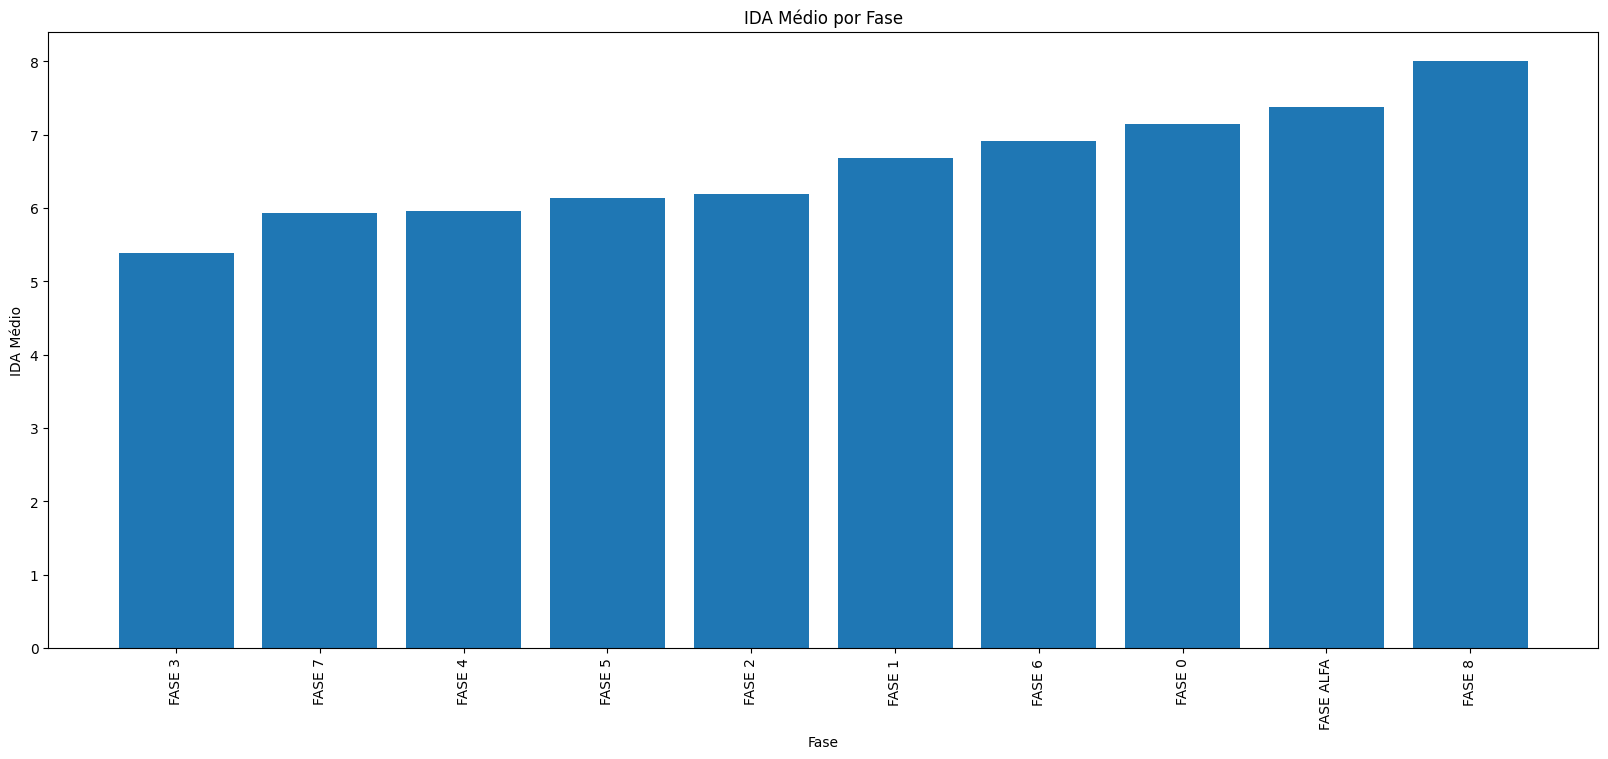

In [23]:
plt.figure(figsize=(20,8))

plt.bar(
    ida_fase["MACRO_FASE"],
    ida_fase["IDA"]
)

plt.title("IDA Médio por Fase")
plt.xlabel("Fase")
plt.ylabel("IDA Médio")

plt.xticks(rotation=90)

plt.show()

### IDA por PEDRA

In [24]:
# Limpeza da coluna pedra
df_final["PEDRA"] = (
    df_final["PEDRA"]
    .replace(["NAN", "INCLUIR", "nan", "NaN"], np.nan)
)

df_final["PEDRA"] = (
    df_final["PEDRA"]
    .astype(str)
    .apply(
        lambda x: unicodedata.normalize('NFKD', x)
        .encode('ASCII', 'ignore')
        .decode('utf-8')
    )
    .str.upper()
    .str.strip()
)

In [25]:
ida_pedra = (
    df_final
    .groupby("PEDRA")["IDA"]
    .mean()
    .sort_values()
)

ida_pedra

PEDRA
QUARTZO     3.461973
AGATA       5.264124
NAN         6.042857
AMETISTA    6.807292
TOPAZIO     8.180766
Name: IDA, dtype: float64

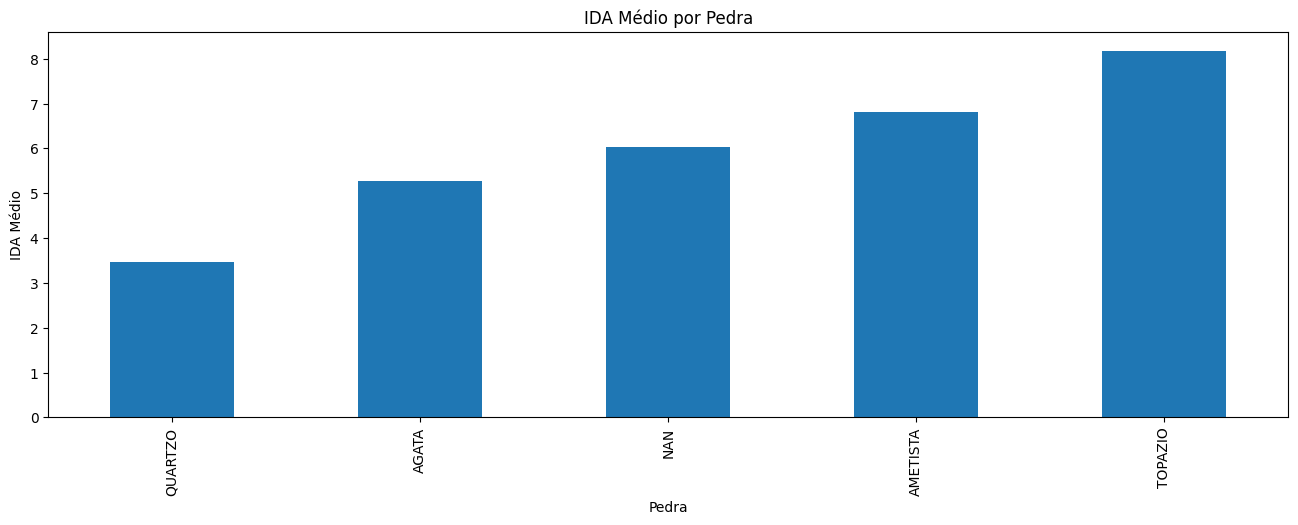

In [26]:
ida_pedra.plot(
    kind="bar",
    figsize=(16,5)
)

plt.title("IDA Médio por Pedra")
plt.ylabel("IDA Médio")
plt.xlabel("Pedra")

plt.show()

### Relação IDA x IAN

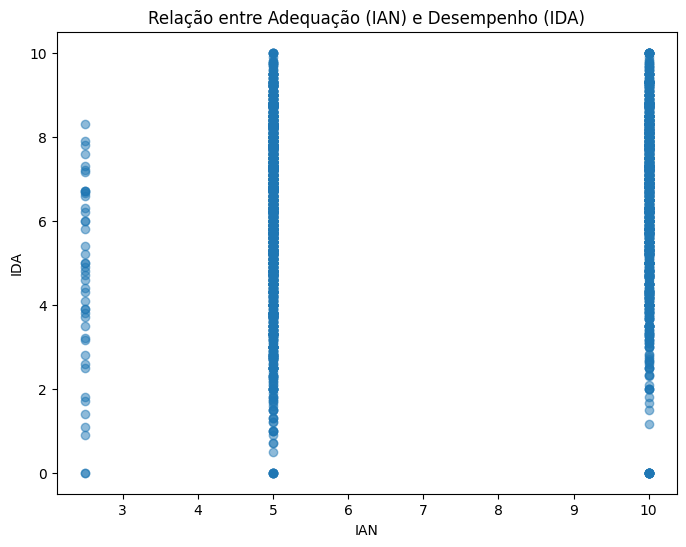

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IAN"],
    df_final["IDA"],
    alpha=0.5
)

plt.xlabel("IAN")
plt.ylabel("IDA")

plt.title("Relação entre Adequação (IAN) e Desempenho (IDA)")

plt.show()

## Evidências encontradas

O desempenho acadêmico apresentou melhora significativa entre 2022 e 2023, seguida de leve redução em 2024, mas ainda mantendo patamar superior ao inicial.

As pedras mais avançadas apresentaram melhores médias de desempenho.

---

## Resposta

O desempenho acadêmico geral demonstra tendência positiva, indicando evolução educacional consistente ao longo do ciclo do programa.

---

# Análise 3: ENGAJAMENTO (IEG)

## Pergunta de negócio

O engajamento dos alunos possui relação com desempenho acadêmico e ponto de virada?

---

## Estratégia analítica

Foram calculadas correlações entre:

- IEG
- IDA
- IPV
- INDE

Também foram realizadas análises visuais e segmentação por faixas de engajamento.

In [28]:
df_final["IEG"].describe()

count    2954.000000
mean        7.945696
std         2.152281
min         0.000000
25%         7.300000
50%         8.600000
75%         9.400000
max        10.000000
Name: IEG, dtype: float64

### Correlação entre indicadores

In [29]:
corr = df_final[
    ["IEG", "IDA", "IPV", "IAN", "INDE"]
].corr()

corr

,IEG,IDA,IPV,IAN,INDE
IEG,1.000000,0.539057,0.558200,-0.060345,0.789472
IDA,0.539057,1.000000,0.557072,0.118487,0.805507
IPV,0.558200,0.557072,1.000000,0.148880,0.767725
IAN,-0.060345,0.118487,0.148880,1.000000,0.400511
INDE,0.789472,0.805507,0.767725,0.400511,1.000000


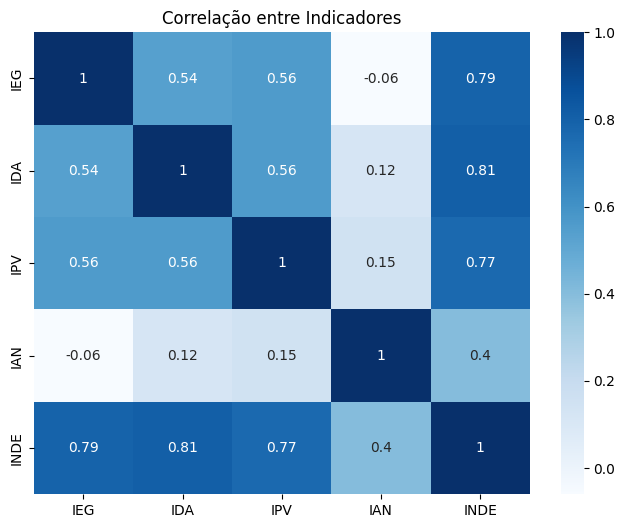

In [30]:

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlação entre Indicadores")

plt.show()

### Relação visual IEG x IDA

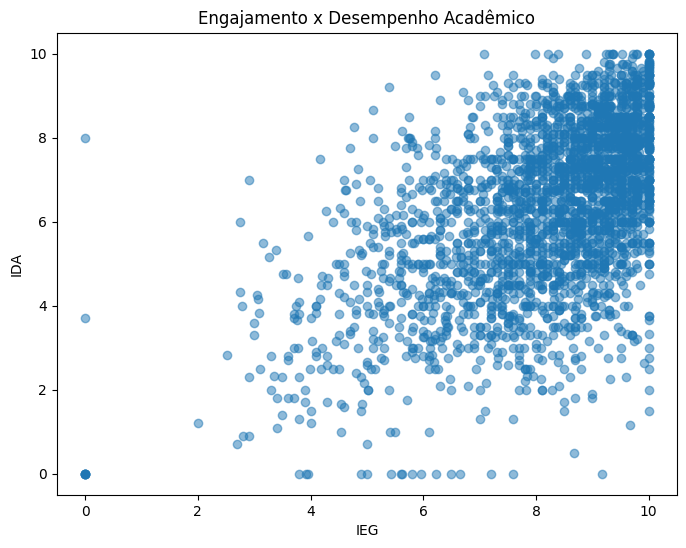

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IEG"],
    df_final["IDA"],
    alpha=0.5
)

plt.xlabel("IEG")
plt.ylabel("IDA")

plt.title("Engajamento x Desempenho Acadêmico")

plt.show()

### Relação IEG x IPV

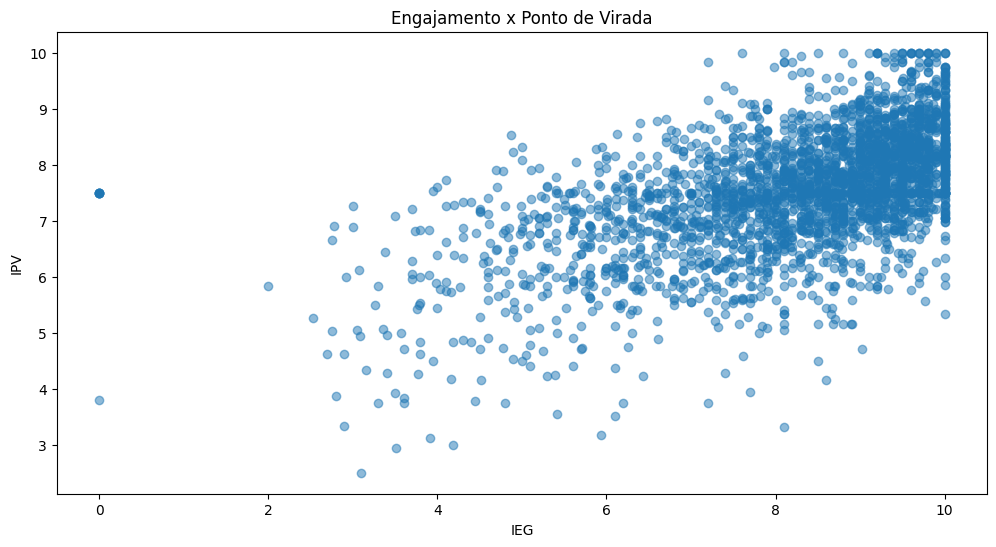

In [32]:
plt.figure(figsize=(12,6))

plt.scatter(
    df_final["IEG"],
    df_final["IPV"],
    alpha=0.5
)

plt.xlabel("IEG")
plt.ylabel("IPV")

plt.title("Engajamento x Ponto de Virada")

plt.show()

### Comparação de  quem atingiu ponto de virada

In [33]:
pv_engajamento = (
    df_final
    .groupby("PONTO_VIRADA")["IEG"]
    .mean()
)

pv_engajamento

PONTO_VIRADA
Não    7.721687
Sim    9.011504
Name: IEG, dtype: float64

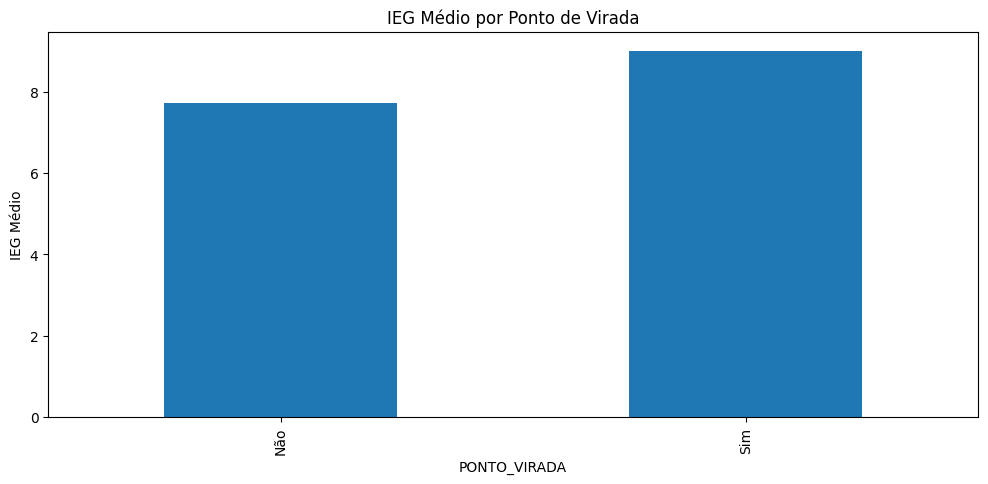

In [34]:
pv_engajamento.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("IEG Médio por Ponto de Virada")
plt.ylabel("IEG Médio")

plt.show()

### Faixas de engajamento

In [35]:
def faixa_ieg(x):

    if pd.isna(x):
        return np.nan

    elif x >= 8:
        return "ALTO"

    elif x >= 6:
        return "MODERADO"

    else:
        return "BAIXO"

df_final["FAIXA_IEG"] = df_final["IEG"].apply(faixa_ieg)

In [36]:
pd.crosstab(
    df_final["FAIXA_IEG"],
    df_final["FAIXA_IAN"],
    normalize="index"
) * 100

FAIXA_IAN,ADEQUADO,DEFASAGEM MODERADA,DEFASAGEM SEVERA
FAIXA_IEG,,,
ALTO,44.698988,54.395312,0.905701
BAIXO,50.663130,45.092838,4.244032
MODERADO,34.142857,64.142857,1.714286


## Evidências encontradas

O IEG apresentou forte correlação positiva com:

- IDA;
- IPV;
- INDE.

Alunos com maior engajamento apresentaram melhor desempenho acadêmico e maior probabilidade de atingir ponto de virada.

---

## Resposta

O engajamento demonstrou ser um dos principais fatores associados ao sucesso educacional dos alunos.

---

## Insight para a Passos Mágicos

Ações voltadas para aumento de participação e engajamento podem gerar impacto direto no desempenho acadêmico e no desenvolvimento global dos estudantes.

# ANÁLISE 4: AUTOAVALIAÇÃO (IAA)

“As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?”

## Estratégia analítica

Foram avaliadas correlações entre:

- IAA;
- IDA;
- IEG;
- IPV;
- INDE.


In [37]:
df_final["IAA"].describe()

count    2865.000000
mean        7.918225
std         2.626209
min         0.000000
25%         7.900000
50%         8.751000
75%         9.500000
max        10.002000
Name: IAA, dtype: float64

In [38]:
corr_iaa = df_final[
    ["IAA", "IDA", "IEG", "IPV", "INDE"]
].corr()

corr_iaa

,IAA,IDA,IEG,IPV,INDE
IAA,1.000000,0.115241,0.133078,0.062728,0.413059
IDA,0.115241,1.000000,0.539057,0.557072,0.805507
IEG,0.133078,0.539057,1.000000,0.558200,0.789472
IPV,0.062728,0.557072,0.558200,1.000000,0.767725
INDE,0.413059,0.805507,0.789472,0.767725,1.000000


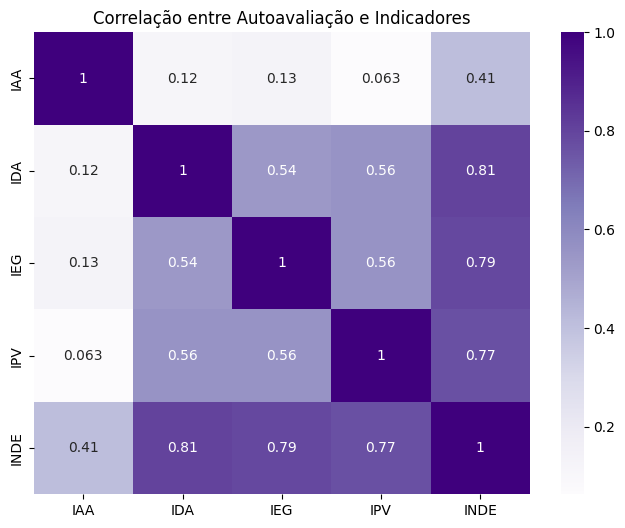

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_iaa,
    annot=True,
    cmap="Purples"
)

plt.title("Correlação entre Autoavaliação e Indicadores")

plt.show()

## IAA x IDA

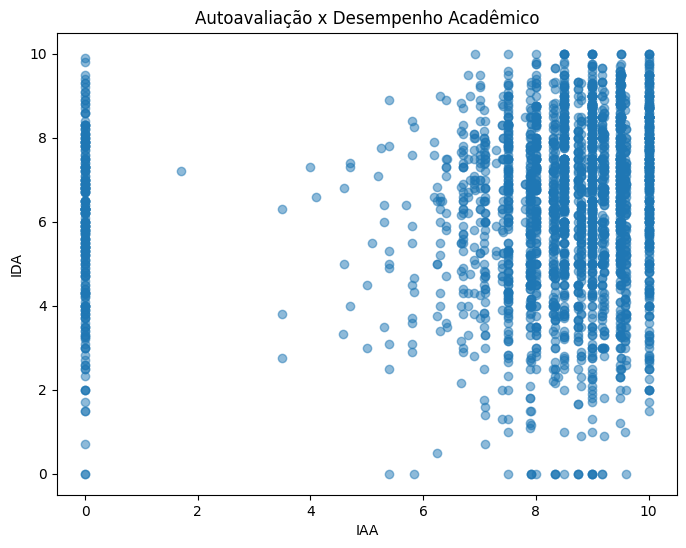

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IAA"],
    df_final["IDA"],
    alpha=0.5
)

plt.xlabel("IAA")
plt.ylabel("IDA")

plt.title("Autoavaliação x Desempenho Acadêmico")

plt.show()

### GAP_PERCEPCAO = IAA - IDA

In [41]:
df_final["GAP_PERCEPCAO"] = (
    df_final["IAA"] - df_final["IDA"]
)

### Distribuição do GAP

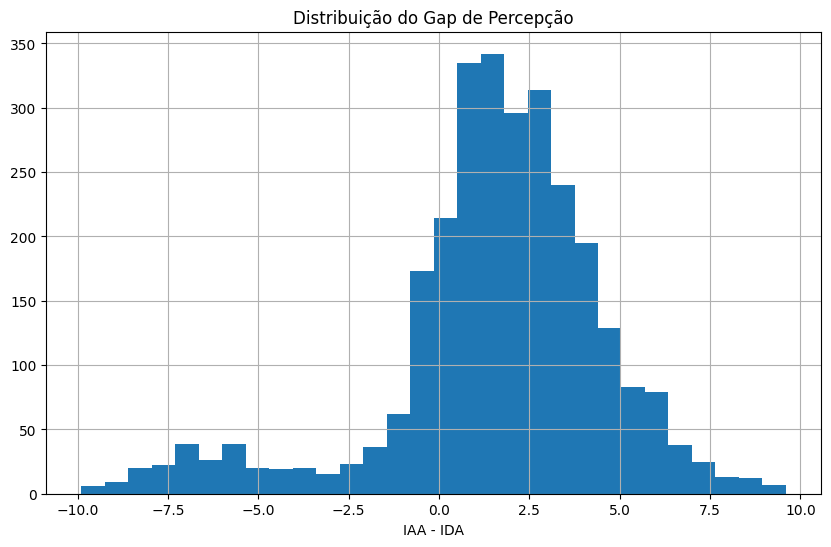

In [42]:
plt.figure(figsize=(10,6))

df_final["GAP_PERCEPCAO"].hist(
    bins=30
)

plt.title("Distribuição do Gap de Percepção")

plt.xlabel("IAA - IDA")

plt.show()

### Gráfico de percepção

In [43]:
def perfil_percepcao(x):

    if pd.isna(x):
        return np.nan

    elif x >= 2:
        return "SUPERCONFIANTE"

    elif x <= -2:
        return "SUBESTIMAÇÃO"

    else:
        return "PERCEPÇÃO COERENTE"

df_final["PERFIL_PERCEPCAO"] = (
    df_final["GAP_PERCEPCAO"]
    .apply(perfil_percepcao)
)

In [44]:
df_final["PERFIL_PERCEPCAO"].value_counts()

PERFIL_PERCEPCAO
SUPERCONFIANTE        1378
PERCEPÇÃO COERENTE    1210
SUBESTIMAÇÃO           263
Name: count, dtype: int64

In [45]:
perfil_ieg = (
    df_final
    .groupby("PERFIL_PERCEPCAO")["IEG"]
    .mean()
)

perfil_ieg

PERFIL_PERCEPCAO
PERCEPÇÃO COERENTE    8.766298
SUBESTIMAÇÃO          7.963794
SUPERCONFIANTE        7.811820
Name: IEG, dtype: float64

### Relação IAA x IPV

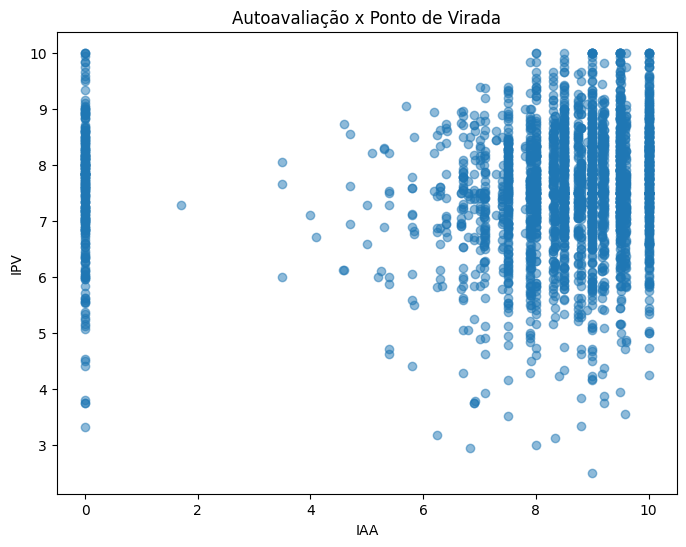

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IAA"],
    df_final["IPV"],
    alpha=0.5
)

plt.xlabel("IAA")
plt.ylabel("IPV")

plt.title("Autoavaliação x Ponto de Virada")

plt.show()

## Evidências encontradas

- Observou-se que parte dos alunos apresenta desalinhamento entre percepção pessoal e desempenho acadêmico, indicando potenciais oportunidades de acompanhamento psicopedagógico e fortalecimento socioemocional.
- A autoavaliação apresentou correlação moderada com INDE, porém baixa relação direta com desempenho acadêmico.

Isso sugere que percepção pessoal nem sempre reflete desempenho real.

## Resposta

Os alunos possuem percepção parcialmente coerente sobre seu desempenho, mas fatores emocionais e subjetivos parecem influenciar fortemente a autoavaliação.

---

# ANÁLISE 5 : ASPECTOS PSICOSSOCIAIS (IPS)

## Pergunta de negócio

Existem padrões psicossociais que antecedem queda de desempenho ou engajamento?

---

## Estratégia analítica

Foram avaliadas:

- Correlações entre IPS e demais indicadores;
- Faixas psicossociais;
- Relação entre IPS e ponto de virada.

---

In [47]:
#Estatísticas básicas
df_final["IPS"].describe()

count    2859.000000
mean        6.287129
std         1.792491
min         2.500000
25%         5.020000
50%         7.500000
75%         7.510000
max        10.000000
Name: IPS, dtype: float64

In [48]:
#Correlação geral
corr_ips = df_final[
    ["IPS", "IDA", "IEG", "IPV", "IAN", "INDE"]
].corr()

corr_ips

,IPS,IDA,IEG,IPV,IAN,INDE
IPS,1.000000,0.022485,-0.046264,-0.048750,0.004548,0.230417
IDA,0.022485,1.000000,0.539057,0.557072,0.118487,0.805507
IEG,-0.046264,0.539057,1.000000,0.558200,-0.060345,0.789472
IPV,-0.048750,0.557072,0.558200,1.000000,0.148880,0.767725
IAN,0.004548,0.118487,-0.060345,0.148880,1.000000,0.400511
INDE,0.230417,0.805507,0.789472,0.767725,0.400511,1.000000


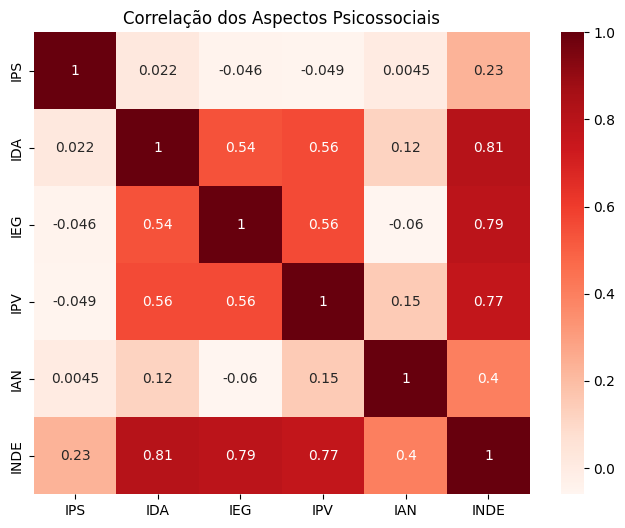

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_ips,
    annot=True,
    cmap="Reds"
)

plt.title("Correlação dos Aspectos Psicossociais")

plt.show()

### IPS x IDA

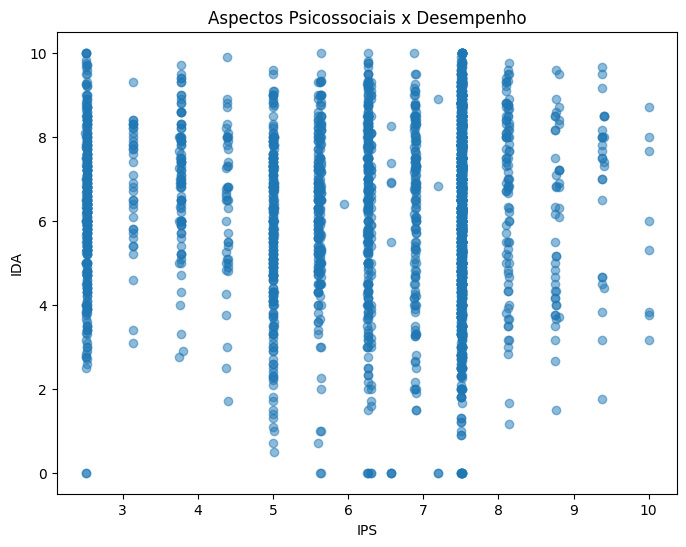

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IPS"],
    df_final["IDA"],
    alpha=0.5
)

plt.xlabel("IPS")
plt.ylabel("IDA")

plt.title("Aspectos Psicossociais x Desempenho")

plt.show()

### IPS x IEG

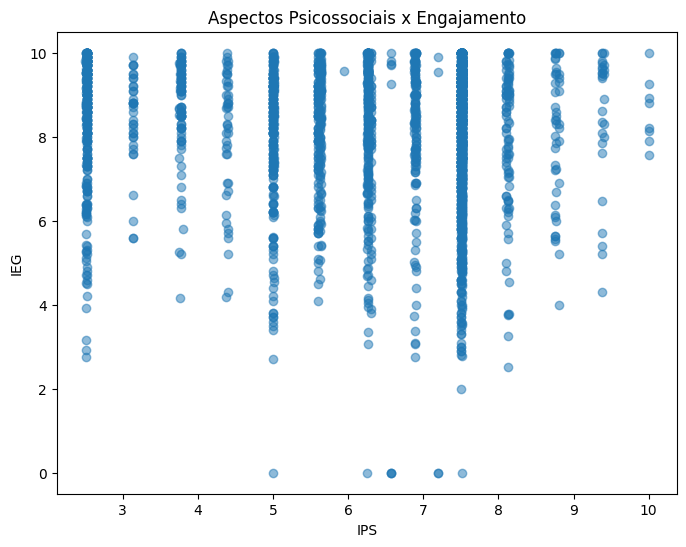

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_final["IPS"],
    df_final["IEG"],
    alpha=0.5
)

plt.xlabel("IPS")
plt.ylabel("IEG")

plt.title("Aspectos Psicossociais x Engajamento")

plt.show()

### Faixas psicossociais

In [52]:
def faixa_ips(x):

    if pd.isna(x):
        return np.nan

    elif x >= 8:
        return "ESTÁVEL"

    elif x >= 6:
        return "ATENÇÃO"

    else:
        return "CRÍTICO"

df_final["FAIXA_IPS"] = (
    df_final["IPS"]
    .apply(faixa_ips)
)

In [53]:
#Distribuição das faixas
df_final["FAIXA_IPS"].value_counts(normalize=True) * 100

FAIXA_IPS
ATENÇÃO    61.210213
CRÍTICO    32.738720
ESTÁVEL     6.051067
Name: proportion, dtype: float64

In [54]:
pd.crosstab(
    df_final["FAIXA_IPS"],
    df_final["FAIXA_IAN"],
    normalize="index"
) * 100

FAIXA_IAN,ADEQUADO,DEFASAGEM MODERADA,DEFASAGEM SEVERA
FAIXA_IPS,,,
ATENÇÃO,39.828571,58.971429,1.200000
CRÍTICO,39.529915,58.119658,2.350427
ESTÁVEL,63.583815,35.838150,0.578035


### IPS e Ponto de Virada

In [55]:
ips_pv = (
    df_final
    .groupby("PONTO_VIRADA")["IPS"]
    .mean()
)

ips_pv

PONTO_VIRADA
Não    6.842972
Sim    7.315044
Name: IPS, dtype: float64

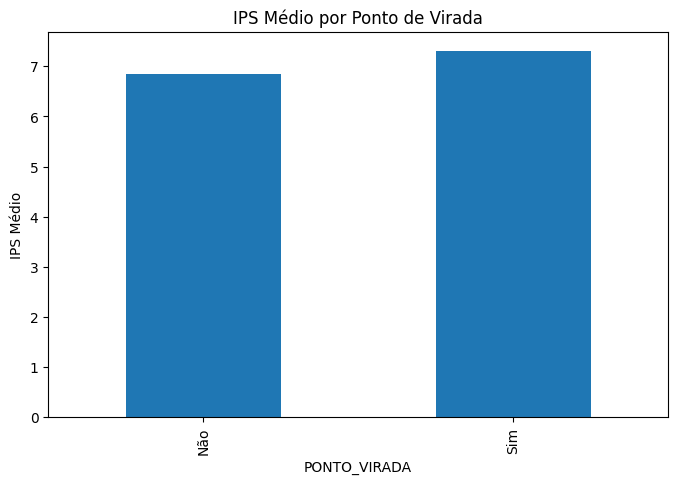

In [56]:
ips_pv.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("IPS Médio por Ponto de Virada")

plt.ylabel("IPS Médio")

plt.show()

### Detecção do grupo de risco

In [57]:
grupo_risco = df_final[
    (df_final["IPS"] < 6) &
    (df_final["IEG"] < 6) &
    (df_final["IDA"] < 6)
]

grupo_risco.shape

(60, 32)

## Evidências encontradas

O IPS apresentou correlação fraca com desempenho acadêmico direto, porém alunos em situação psicossocial crítica apresentaram maior concentração de defasagem moderada.

---

## Resposta

Aspectos psicossociais parecem atuar mais como fatores complementares do que como causa isolada do desempenho acadêmico.

---

# ANÁLISE 6: IPP (Psicopedagógico)

## Pergunta de negócio

As avaliações psicopedagógicas confirmam a defasagem identificada pelo IAN?

---

## Estratégia analítica

Foi analisada a relação entre:

- IPP;
- IAN;
- IDA;
- IPV;
- INDE.

---

In [58]:
df_final["IPP"].isna().mean() * 100

34.25742574257426

In [59]:
# Base apenas com IPP válido
df_ipp = df_final.dropna(subset=["IPP"]).copy()

In [60]:
df_ipp["IPP"].describe()

count    1992.000000
mean        7.555203
std         0.938990
min         2.500000
25%         7.083333
50%         7.500000
75%         8.125000
max        10.000000
Name: IPP, dtype: float64

### Correlação IPP x IAN

In [61]:
corr_ipp = df_ipp[
    ["IPP", "IAN", "IDA", "IEG", "IPV", "INDE"]
].corr()

corr_ipp

,IPP,IAN,IDA,IEG,IPV,INDE
IPP,1.000000,0.123398,0.369218,0.328542,0.606649,0.637097
IAN,0.123398,1.000000,0.087980,0.088006,0.131533,0.365568
IDA,0.369218,0.087980,1.000000,0.524300,0.520257,0.801985
IEG,0.328542,0.088006,0.524300,1.000000,0.527040,0.786891
IPV,0.606649,0.131533,0.520257,0.527040,1.000000,0.758006
INDE,0.637097,0.365568,0.801985,0.786891,0.758006,1.000000


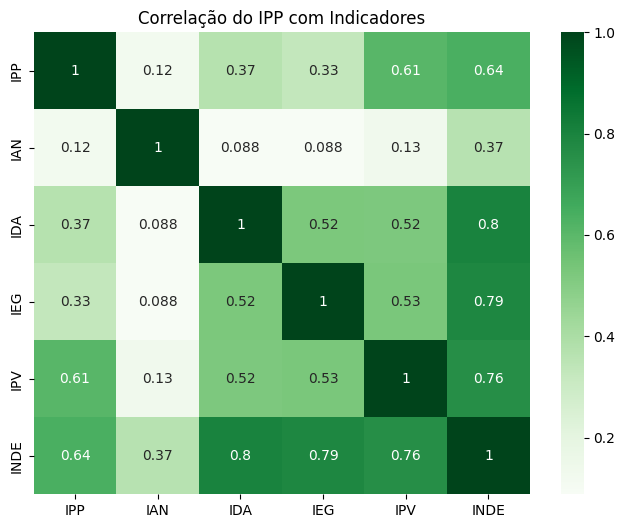

In [62]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_ipp,
    annot=True,
    cmap="Greens"
)

plt.title("Correlação do IPP com Indicadores")

plt.show()

### IPP x IAN

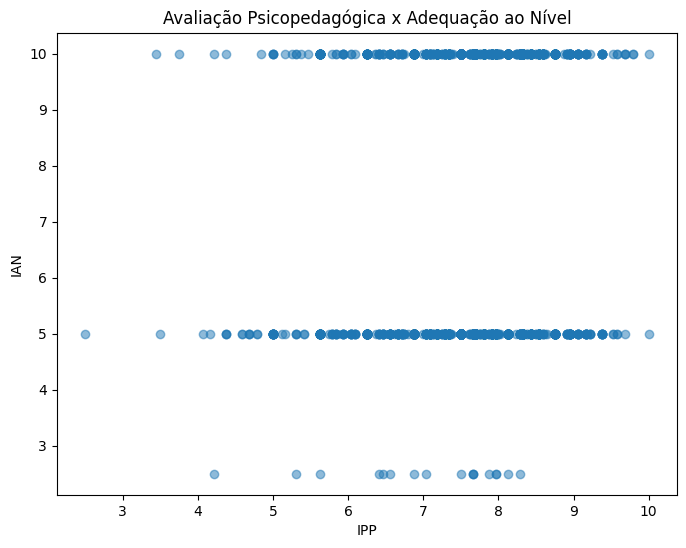

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_ipp["IPP"],
    df_ipp["IAN"],
    alpha=0.5
)

plt.xlabel("IPP")
plt.ylabel("IAN")

plt.title("Avaliação Psicopedagógica x Adequação ao Nível")

plt.show()

### Criação do indicador de divergência

In [64]:
df_ipp["GAP_IPP_IAN"] = (
    df_ipp["IPP"] - df_ipp["IAN"]
)

## Evidências encontradas

O IPP apresentou forte correlação com IPV e INDE, demonstrando alta capacidade de explicar desenvolvimento global.

---

## Resposta

As avaliações psicopedagógicas reforçam os padrões identificados nos demais indicadores educacionais.

---


# ANÁLISE 7 : PONTO DE VIRADA (IPV) 

## Pergunta de negócio

Quais fatores mais influenciam o ponto de virada dos alunos?

---

## Estratégia analítica

Foi realizado ranking de correlação entre IPV e demais indicadores.

---


### Estatísticas básicas

In [65]:
df_final["IPV"].describe()

count    2852.000000
mean        7.545476
std         1.084347
min         2.500000
25%         6.984000
50%         7.583000
75%         8.255000
max        10.010000
Name: IPV, dtype: float64

### Correlação geral com IPV

In [66]:
corr_ipv = df_final[
    ["IPV", "IDA", "IEG", "IAA", "IPS", "IPP", "IAN", "INDE"]
].corr()

corr_ipv

,IPV,IDA,IEG,IAA,IPS,IPP,IAN,INDE
IPV,1.000000,0.557072,0.558200,0.062728,-0.048750,0.606649,0.148880,0.767725
IDA,0.557072,1.000000,0.539057,0.115241,0.022485,0.369218,0.118487,0.805507
IEG,0.558200,0.539057,1.000000,0.133078,-0.046264,0.328542,-0.060345,0.789472
IAA,0.062728,0.115241,0.133078,1.000000,0.157373,0.054461,0.034162,0.413059
IPS,-0.048750,0.022485,-0.046264,0.157373,1.000000,0.064209,0.004548,0.230417
IPP,0.606649,0.369218,0.328542,0.054461,0.064209,1.000000,0.123398,0.637097
IAN,0.148880,0.118487,-0.060345,0.034162,0.004548,0.123398,1.000000,0.400511
INDE,0.767725,0.805507,0.789472,0.413059,0.230417,0.637097,0.400511,1.000000


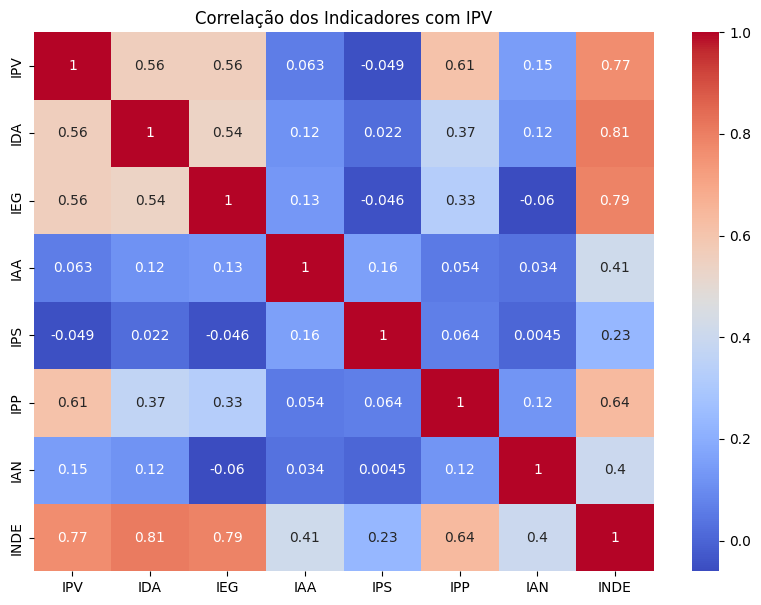

In [67]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_ipv,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação dos Indicadores com IPV")

plt.show()

### Ranking de influência

In [68]:
corr_com_ipv = (
    corr_ipv["IPV"]
    .drop("IPV")
    .sort_values(ascending=False)
)

corr_com_ipv

INDE    0.767725
IPP     0.606649
IEG     0.558200
IDA     0.557072
IAN     0.148880
IAA     0.062728
IPS    -0.048750
Name: IPV, dtype: float64

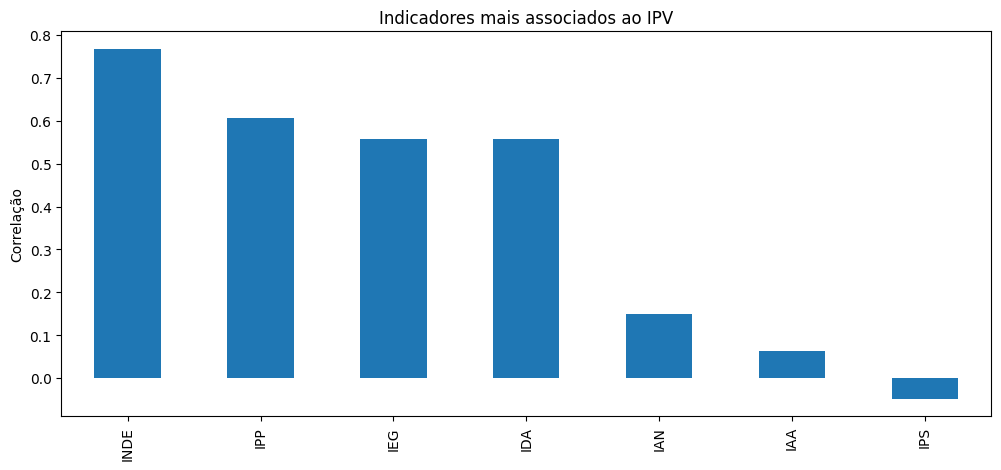

In [69]:
corr_com_ipv.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Indicadores mais associados ao IPV")

plt.ylabel("Correlação")

plt.show()

### Comparação de quem atingiu ponto de virada

In [70]:
indicadores_pv = (
    df_final
    .groupby("PONTO_VIRADA")
    .agg({
        "IDA": "mean",
        "IEG": "mean",
        "IAA": "mean",
        "IPS": "mean",
        "IPP": "mean",
        "IAN": "mean",
        "INDE": "mean"
    })
)


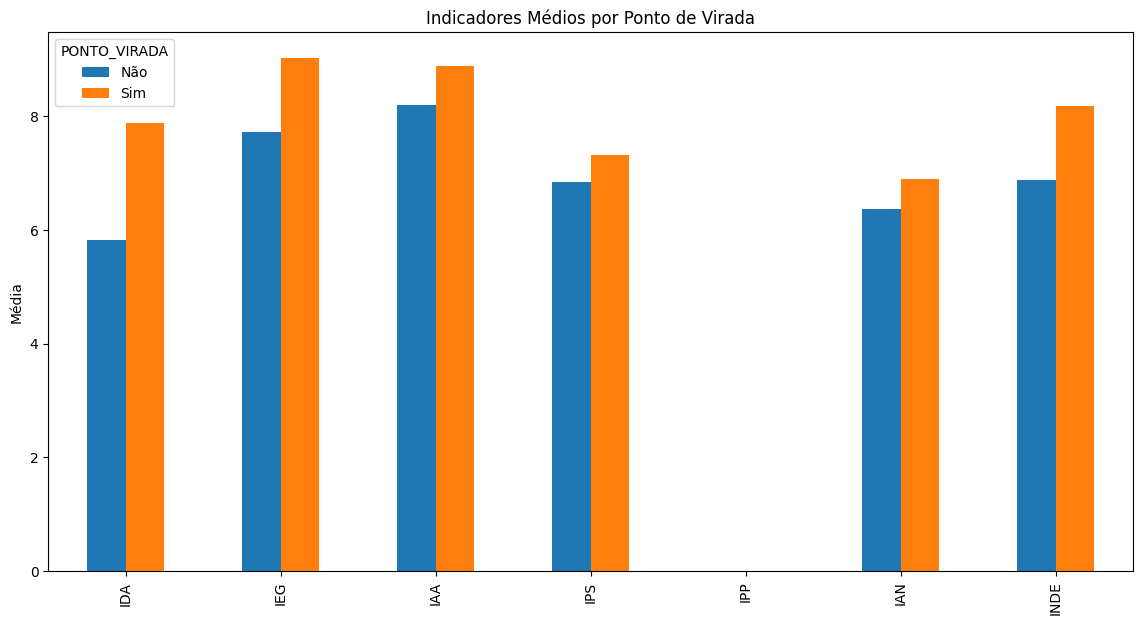

In [71]:
indicadores_pv.T.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Indicadores Médios por Ponto de Virada")

plt.ylabel("Média")

plt.show()

### Evolução do IPV ao longo dos anos

In [72]:
ipv_ano = (
    df_final
    .groupby("ANO")["IPV"]
    .mean()
)

ipv_ano

ANO
2022    7.253642
2023    8.027897
2024    7.354268
Name: IPV, dtype: float64

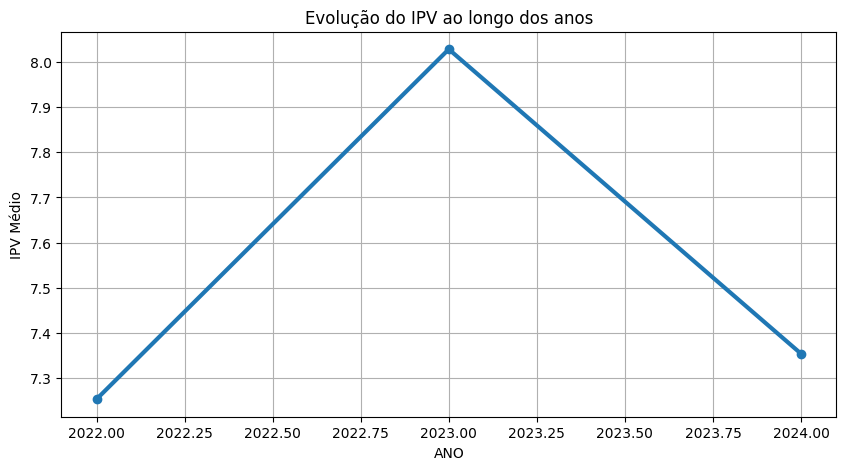

In [73]:
ipv_ano.plot(
    marker="o",
    linewidth=3,
    figsize=(10,5)
)

plt.title("Evolução do IPV ao longo dos anos")

plt.ylabel("IPV Médio")

plt.grid(True)

plt.show()

In [74]:
#Detectar perfil de alto IPV
df_final["ALTO_IPV"] = np.where(
    df_final["IPV"] >= 8,
    1,
    0
)

In [75]:
alto_ipv = (
    df_final
    .groupby("ALTO_IPV")[
        ["IDA", "IEG", "IAA", "IPS", "IPP", "IAN"]
    ]
    .mean()
)

alto_ipv

,IDA,IEG,IAA,IPS,IPP,IAN
ALTO_IPV,,,,,,
0,5.765718,7.386541,7.873368,6.383352,7.235162,7.029642
1,7.525497,9.056656,8.003313,6.105192,8.045227,7.487361


## Evidências encontradas

Os fatores mais associados ao IPV foram:

1. INDE;
2. IPP;
3. IEG;
4. IDA.

---

## Resposta

O ponto de virada parece estar fortemente relacionado à combinação entre desempenho acadêmico, engajamento e acompanhamento psicopedagógico.

---


# Análise 8 — Multidimensionalidade dos Indicadores

## Pergunta de negócio

Quais combinações de indicadores mais influenciam o INDE?

---

## Estratégia analítica

Foram utilizadas:

- Correlação;
- Regressão linear;
- PCA.

---

In [76]:
corr_inde = df_final[
    ["INDE", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN"]
].corr()

corr_inde

,INDE,IDA,IEG,IAA,IPS,IPP,IPV,IAN
INDE,1.000000,0.805507,0.789472,0.413059,0.230417,0.637097,0.767725,0.400511
IDA,0.805507,1.000000,0.539057,0.115241,0.022485,0.369218,0.557072,0.118487
IEG,0.789472,0.539057,1.000000,0.133078,-0.046264,0.328542,0.558200,-0.060345
IAA,0.413059,0.115241,0.133078,1.000000,0.157373,0.054461,0.062728,0.034162
IPS,0.230417,0.022485,-0.046264,0.157373,1.000000,0.064209,-0.048750,0.004548
IPP,0.637097,0.369218,0.328542,0.054461,0.064209,1.000000,0.606649,0.123398
IPV,0.767725,0.557072,0.558200,0.062728,-0.048750,0.606649,1.000000,0.148880
IAN,0.400511,0.118487,-0.060345,0.034162,0.004548,0.123398,0.148880,1.000000


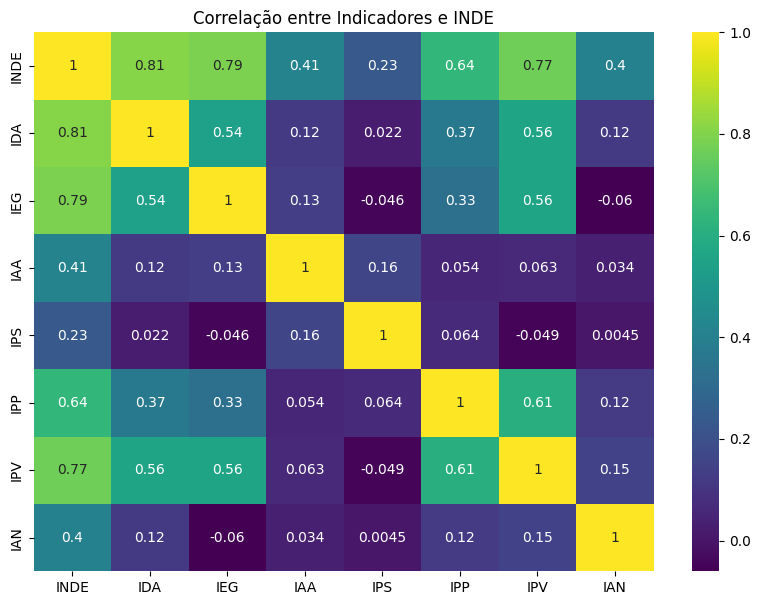

In [77]:

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_inde,
    annot=True,
    cmap="viridis"
)

plt.title("Correlação entre Indicadores e INDE")

plt.show()

### Ranking de influência

In [78]:
impacto_inde = (
    corr_inde["INDE"]
    .drop("INDE")
    .sort_values(ascending=False)
)

impacto_inde

IDA    0.805507
IEG    0.789472
IPV    0.767725
IPP    0.637097
IAA    0.413059
IAN    0.400511
IPS    0.230417
Name: INDE, dtype: float64

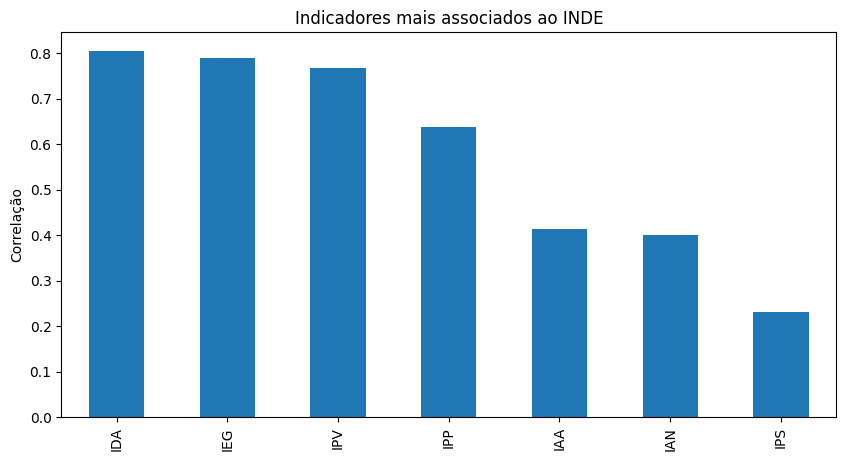

In [79]:
impacto_inde.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Indicadores mais associados ao INDE")

plt.ylabel("Correlação")

plt.show()

### Análise Multivariada

In [80]:
#Preparar dados
base_modelo = df_final[
    ["IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN", "INDE"]
].dropna()

In [81]:
#features e target
X = base_modelo[
    ["IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN"]
]

y = base_modelo["INDE"]

In [82]:
#treinar modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X, y)

LinearRegression()

In [83]:
# coeficientes
coeficientes = pd.DataFrame({
    "Indicador": X.columns,
    "Peso": modelo_lr.coef_
})

coeficientes.sort_values(
    "Peso",
    ascending=False
)

,Indicador,Peso
0,IDA,0.2
1,IEG,0.2
5,IPV,0.2
3,IPS,0.1
2,IAA,0.1
6,IAN,0.1
4,IPP,0.1


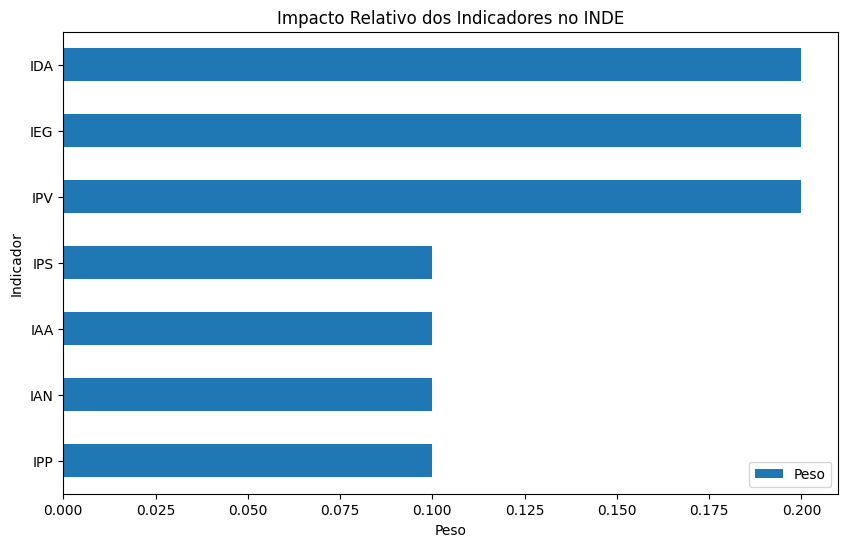

In [84]:
coeficientes.sort_values(
    "Peso"
).plot(
    x="Indicador",
    y="Peso",
    kind="barh",
    figsize=(10,6)
)

plt.title("Impacto Relativo dos Indicadores no INDE")

plt.xlabel("Peso")

plt.show()

## Evidências encontradas

Os indicadores com maior influência no INDE foram:

- IDA;
- IEG;
- IPV;
- IPP.

---

## Resposta

O desempenho global dos alunos depende principalmente da combinação entre desempenho acadêmico, engajamento e evolução comportamental.

---

## Insight para a Passos Mágicos

A evolução dos alunos ocorre de forma integrada, reforçando a importância de uma abordagem educacional multidimensional.

### PCA

In [85]:
dados_pca = base_modelo.drop(columns="INDE")

scaler = StandardScaler()

dados_scaled = scaler.fit_transform(dados_pca)

pca = PCA(n_components=2)

componentes = pca.fit_transform(dados_scaled)

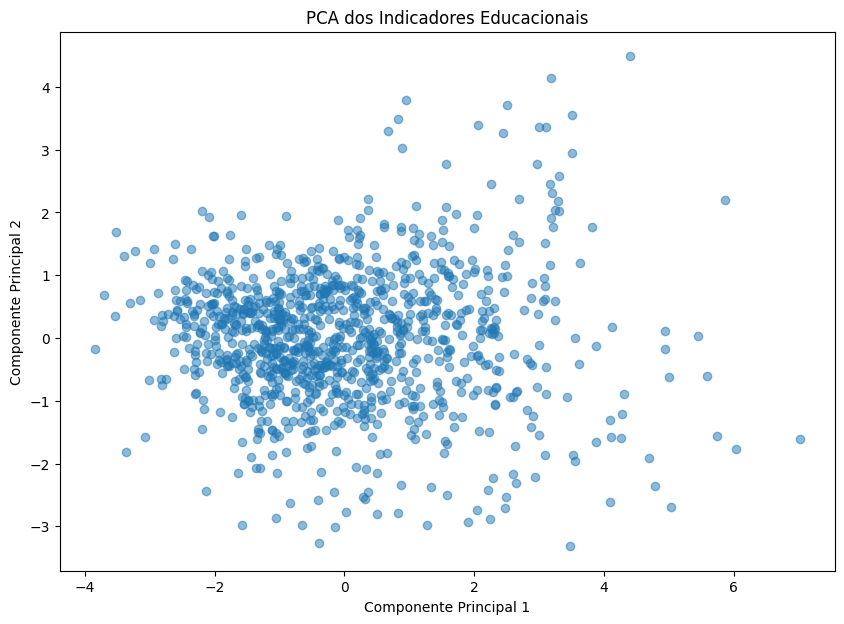

In [86]:
plt.figure(figsize=(10,7))

plt.scatter(
    componentes[:,0],
    componentes[:,1],
    alpha=0.5
)

plt.title("PCA dos Indicadores Educacionais")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

## MACHINE LEARNING

## Objetivo
- Determinar quais padrões permitem identificar alunos em risco antes da queda no desempenho
- Desenvolver um modelo capaz de prever risco educacional antes do agravamento da defasagem.

A partir das análises , decidi que prever risco educacional seria o mais importante. Criarei um modelo que preveja RISCO = 1.

### 1 - Criando Target

In [87]:
# Critério	Regra
# Defasagem	IAN <= 5
# Baixo desempenho	IDA < 6
# Baixo engajamento	IEG < 6

df_ml = df_final.copy()

df_ml["RISCO"] = np.where(
    (
        (df_ml["IAN"] <= 5) |
        (df_ml["IDA"] < 6) |
        (df_ml["IEG"] < 6)
    ),
    1,
    0
)

### Distribuição

In [88]:
df_ml["RISCO"].value_counts(normalize=True) * 100

RISCO
1    72.112211
0    27.887789
Name: proportion, dtype: float64

### 2 - Features

In [89]:
features = [
    "IAA",
    "IPS",
    "IPP",
    "PEDRA",
    "MACRO_FASE",
    "IDADE",
    "GENERO",
    "ANO_INGRESSO"
]

### 3 - Selecionando Base

In [90]:
df_modelo = df_ml[
    features + ["RISCO"]
].copy()

### 4 - Tratando Nulos

In [91]:
df_modelo["IDADE"] = pd.to_numeric(
    df_modelo["IDADE"],
    errors="coerce"
)

categoricas = [
    "PEDRA",
    "MACRO_FASE",
    "GENERO"
]
numericas = [
    "IAA",
    "IPS",
    "IPP",
    "IDADE",
    "ANO_INGRESSO"
]
for col in numericas:
    df_modelo[col] = (
        df_modelo[col]
        .fillna(df_modelo[col].median())
    )

for col in categoricas:
    df_modelo[col] = (
        df_modelo[col]
        .fillna("DESCONHECIDO")
    )

### 5 - Encoding

In [92]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=categoricas,
    drop_first=True
)

### 6 - Criando X e Y

In [93]:
X = df_modelo.drop("RISCO", axis=1)

y = df_modelo["RISCO"]

### 7 - Train Test Split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 8 - Randon Forest

## Modelo escolhido

Foi utilizado o algoritmo Random Forest Classifier.

A escolha ocorreu devido:

- Boa performance em dados tabulares;
- Robustez contra overfitting;
- Capacidade de lidar com relações não lineares;
- Interpretação por importância das variáveis.

---

## Variáveis utilizadas

Foram utilizadas variáveis como:

- IAA;
- IPS;
- IPP;
- Idade;
- Ano de ingresso;
- Pedra;
- Macro fase;
- Gênero.

---


In [95]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

### 9 - Predições

In [96]:
y_pred = modelo_rf.predict(X_test)

y_prob = modelo_rf.predict_proba(X_test)[:,1]

### 10 - Métricas

In [97]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.863036303630363

ROC AUC:
0.9295830907342965

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       169
           1       0.90      0.91      0.91       437

    accuracy                           0.86       606
   macro avg       0.83      0.82      0.83       606
weighted avg       0.86      0.86      0.86       606



O modelo apresentou excelente capacidade discriminatória na identificação de alunos em risco educacional, alcançando ROC-AUC superior a 0.92.

### 11 - Matriz de Confusão

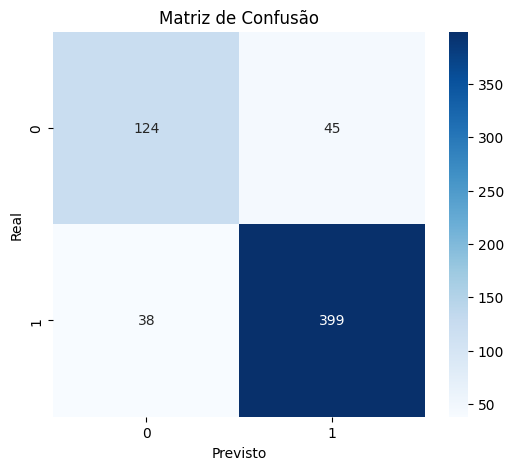

In [98]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão")

plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

### 12 - Feature Importance

In [99]:
importancias = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        "Importancia",
        ascending=False
    )
)

importancias.head(15)

,Feature,Importancia
8,PEDRA_TOPAZIO,0.286095
3,IDADE,0.165662
2,IPP,0.092832
0,IAA,0.079819
1,IPS,0.060100
5,PEDRA_AMETISTA,0.055840
7,PEDRA_QUARTZO,0.050265
4,ANO_INGRESSO,0.048528
16,MACRO_FASE_FASE 8,0.026276
9,MACRO_FASE_FASE 1,0.023602


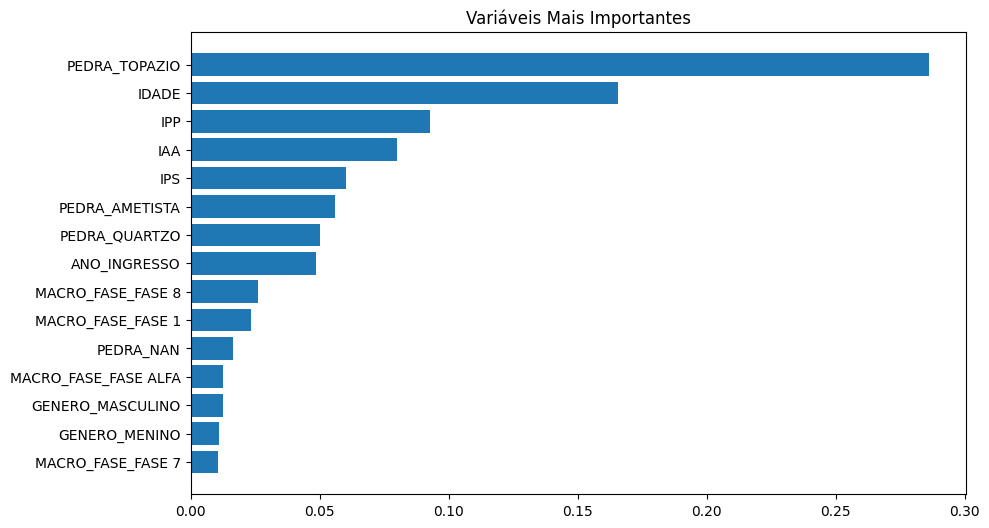

In [100]:
top_features = importancias.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Variáveis Mais Importantes")

plt.show()

## Variáveis mais importantes

As variáveis com maior impacto na previsão foram:

- Pedra;
- Idade;
- IPP;
- IAA;
- IPS.

---

## Conclusão do modelo

Os resultados demonstram que é possível identificar alunos em risco com alta capacidade preditiva, permitindo atuação preventiva da instituição.

## Importação do Joblib

### Salvar Modelo

In [101]:
import joblib
joblib.dump(
    modelo_rf,
    "modelo_risco_educacional.pkl"
)

['modelo_risco_educacional.pkl']

### Salvar features

In [102]:
joblib.dump(
    X.columns.tolist(),
    "features_modelo.pkl"
)

['features_modelo.pkl']

In [103]:
modelo_teste = joblib.load(
    "modelo_risco_educacional.pkl"
)

features_teste = joblib.load(
    "features_modelo.pkl"
)

print(features_teste[:10])

['IAA', 'IPS', 'IPP', 'IDADE', 'ANO_INGRESSO', 'PEDRA_AMETISTA', 'PEDRA_NAN', 'PEDRA_QUARTZO', 'PEDRA_TOPAZIO', 'MACRO_FASE_FASE 1']


# Conclusão Final

Os resultados obtidos indicam impacto positivo da Associação Passos Mágicos no desenvolvimento educacional dos alunos.

As análises demonstraram:

- Evolução da adequação educacional;
- Melhora do desempenho acadêmico;
- Forte influência do engajamento;
- Importância do acompanhamento psicopedagógico;
- Viabilidade de previsão antecipada de risco educacional.

O modelo preditivo desenvolvido pode auxiliar a instituição na identificação precoce de vulnerabilidades, permitindo intervenções mais rápidas e eficazes.

Por fim, o projeto reforça o valor da análise de dados como ferramenta de transformação social e apoio à tomada de decisão educacional.